# 06 - Shipping Mode, Product Category & Numeric Feature Patterns


## Setup


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../../data/raw data/DataCoSupplyChainDataset.csv')  

try:
    df = pd.read_csv(DATA_PATH, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 failed, falling back to ISO-8859-1")
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


UTF-8 failed, falling back to ISO-8859-1
Shape: 180,519 rows x 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Shipping mode & product category

Late delivery rate by Shipping Mode:


,mean,count
Shipping Mode,,
First Class,0.953225,27814
Second Class,0.766328,35216
Same Day,0.457430,9737
Standard Class,0.380717,107752


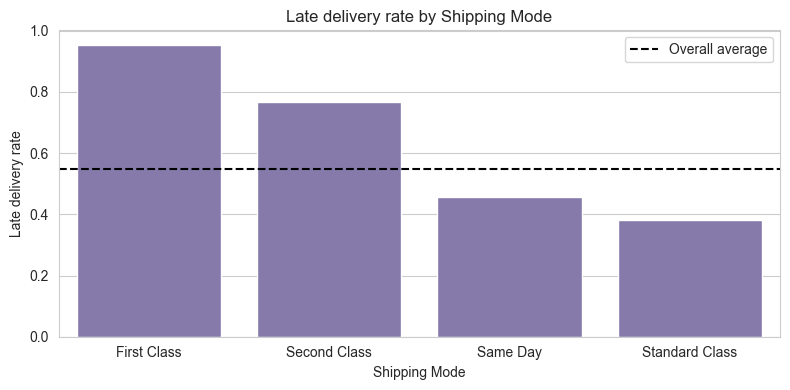

In [3]:
shipping_delay = df.groupby('Shipping Mode')['Late_delivery_risk'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Late delivery rate by Shipping Mode:")
display(shipping_delay)

plt.figure(figsize=(8, 4))
sns.barplot(x=shipping_delay.index, y=shipping_delay['mean'], color='#8172B2')
plt.axhline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', label='Overall average')
plt.ylabel('Late delivery rate')
plt.title('Late delivery rate by Shipping Mode')
plt.legend()
plt.tight_layout()
plt.show()


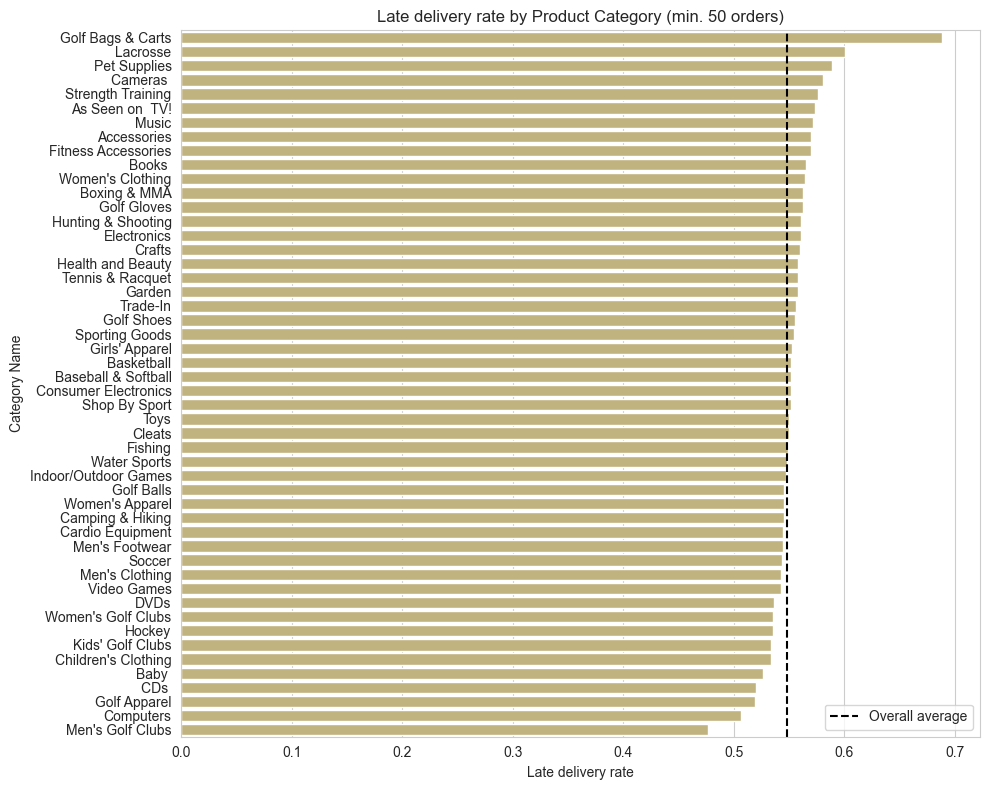

In [4]:
category_delay = df.groupby('Category Name')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
category_delay.columns = ['Category Name', 'late_rate', 'n_orders']
category_delay = category_delay[category_delay['n_orders'] >= 50].sort_values('late_rate', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=category_delay, y='Category Name', x='late_rate', color='#CCB974')
plt.axvline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', label='Overall average')
plt.xlabel('Late delivery rate')
plt.title('Late delivery rate by Product Category (min. 50 orders)')
plt.legend()
plt.tight_layout()
plt.show()


**What we found (categorical):**

**Shipping Mode is, by a huge margin, the strongest signal found anywhere in our EDA so far:**

| Shipping Mode | Late rate | n orders |
|---|---|---|
| First Class | **95.32%** | 27,814 |
| Second Class | 76.63% | 35,216 |
| Same Day | 45.74% | 9,737 |
| Standard Class | 38.07% | 107,752 |

That's a **57 percentage point spread** - vastly wider than anything we found at the region (9pp) or even country (30pp) level. This is a genuinely important, somewhat counter intuitive finding worth understanding *why* it happens, not just reporting the numbers:

**Likely explanation:** `Shipping Mode` is almost certainly tightly coupled to `Days for shipment (scheduled)` - faster promised modes (First Class) likely have a much shorter scheduled delivery window (e.g. 0–1 days) than slower ones (Standard Class, likely 4 days). A tighter promise is mathematically much easier to breach - even a small real world delay counts as "late" against a 1 day promise, but the same delay is absorbed comfortably within a 4 day promise. This isn't a data error; it's a genuine, explainable operational pattern, and it's exactly the kind of insight a SHAP analysis would later confirm with feature importance.

**Two important implications to flag:**
1. **This single feature will likely dominate every model we build.** It's so strong that it validates the rule based baseline strategy already planned in our workflow (flagging "Late" based on Shipping Mode/Region exceeding a delay threshold) - that baseline is going to be a genuinely tough benchmark to beat, not a token comparison point, which is actually a good thing for a rigorous evaluation section.
2. **Worth checking for near multicollinearity in Stage 3/4**: if `Shipping Mode` and `Days for shipment (scheduled)` are almost perfectly correlated (i.e. each mode always maps to the same scheduled days value), including both as separate model inputs may be redundant. Run a quick crosstab (`pd.crosstab(df['Shipping Mode'], df['Days for shipment (scheduled)'])`) in Stage 3 to confirm the relationship before deciding whether to keep both, since a highly interpretable model like Logistic Regression can behave oddly with near duplicate predictors.

**Product Category shows a moderate, more typical spread** - from Golf Bags & Carts (~69% late, the highest) down to Men's Golf Clubs (~48%, the lowest), roughly a 21 percentage point range. Most categories cluster fairly tightly around the ~54–57% overall average, with only a handful of standout categories at either extreme. This is a real but secondary signal - worth including as a feature, but nowhere near as dominant as Shipping Mode.

**`DECISION_LOG.md`:** Shipping Mode identified as the single strongest predictor found in EDA (57pp spread); flag for multicollinearity check against Days for shipment (scheduled) before final feature set is locked in.


## Numeric feature distributions & outliers

In [5]:
numeric_cols_of_interest = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Days for shipment (scheduled)']
numeric_cols_of_interest = [c for c in numeric_cols_of_interest if c in df.columns]

df[numeric_cols_of_interest].describe()


,Sales,Benefit per order,Order Item Quantity,Days for shipment (scheduled)
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,203.772096,21.974989,2.127638,2.931847
std,132.273077,104.433526,1.453451,1.374449
min,9.990000,-4274.979980,1.000000,0.000000
25%,119.980003,7.000000,1.000000,2.000000
50%,199.919998,31.520000,1.000000,4.000000
75%,299.950012,64.800003,3.000000,4.000000
max,1999.989990,911.799988,5.000000,4.000000


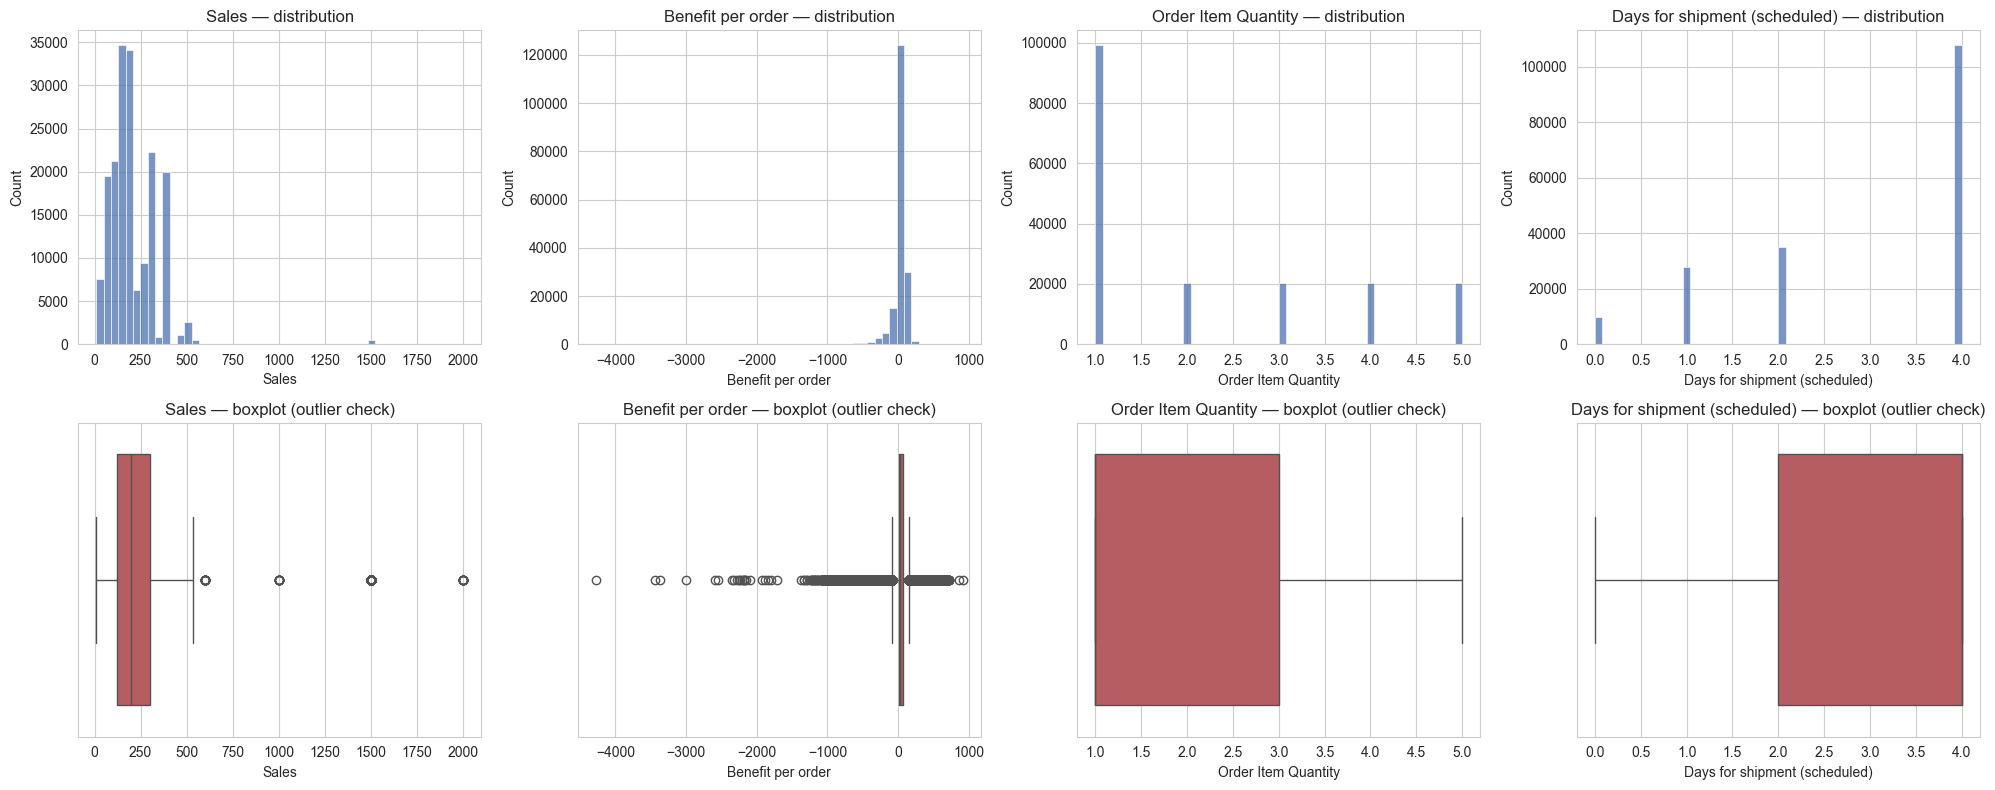

In [6]:
fig, axes = plt.subplots(2, len(numeric_cols_of_interest), figsize=(5*len(numeric_cols_of_interest), 8))

for i, col in enumerate(numeric_cols_of_interest):
    sns.histplot(df[col], bins=50, ax=axes[0, i], color='#4C72B0')
    axes[0, i].set_title(f'{col} — distribution')

    sns.boxplot(x=df[col], ax=axes[1, i], color='#C44E52')
    axes[1, i].set_title(f'{col} — boxplot (outlier check)')

plt.tight_layout()
plt.show()


In [7]:
for col in numeric_cols_of_interest:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_outliers = n_outliers / len(df) * 100
    print(f"{col}: {n_outliers:,} outliers ({pct_outliers:.2f}%) outside [{lower:.2f}, {upper:.2f}]")


Sales: 488 outliers (0.27%) outside [-149.98, 569.91]
Benefit per order: 18,942 outliers (10.49%) outside [-79.70, 151.50]
Order Item Quantity: 0 outliers (0.00%) outside [-2.00, 6.00]
Days for shipment (scheduled): 0 outliers (0.00%) outside [-1.00, 7.00]


**What we found (numeric/outliers):**

| Column | Outliers (IQR method) | Notes |
|---|---|---|
| `Sales` | 488 (0.27%) | Minimal outliers - mildly right-skewed (mean 203.77 vs. max 1999.99) but not a real concern. Safe to use largely as is, light capping optional. |
| `Benefit per order` | **18,942 (10.49%)** | **Significant - this needs real attention in Stage 3.** |
| `Order Item Quantity` | 0 (0.00%) | Discrete, bounded 1–5, no treatment needed. |
| `Days for shipment (scheduled)` | 0 (0.00%) | Discrete, bounded 0–4, no treatment needed. |

**`Benefit per order` is the one column that genuinely needs a deliberate preprocessing decision, and it matters more than usual for our project specifically because of the secondary lens:**

- The range is extreme: **mean of $21.97, but a minimum of –$4,274.98 and maximum of $911.80.** Over 10% of all orders fall outside the normal IQR range - that's a real, substantial share of the data, not a handful of edge cases.
- A single order with a –$4,275 "profit" is almost certainly a genuine large loss (e.g. heavy discounting, a very expensive return, or a data artifact) rather than a data entry error, but it's the kind of extreme value that can badly distort both model training (for algorithms sensitive to scale, like Logistic Regression) and - more importantly for us — **our secondary lens's priority score**, since `risk × order value` would treat a hugely negative profit order in a way that needs explicit design thought (does a big loss order count as "high value" and therefore high priority, or should priority be based on absolute magnitude of business impact regardless of sign, or should we use `Sales` rather than `Benefit per order` for the value term specifically to avoid sign confusion?).
- **Recommended Stage 3 approach:** don't blanket drop these 18,942 rows (that's too much data to discard, ~10% of the dataset). Instead: (1) consider capping/winsorizing extreme values for model training stability, and (2) as a separate, explicit design decision, define exactly how negative profit orders should be treated in the secondary lens's priority formula - this deserves its own line in `DECISION_LOG.md` since it directly affects a core deliverable, not just general data cleaning.

**`DECISION_LOG.md`:** `Benefit per order` has 10.49% outliers including large negative values; decision needed on (1) capping strategy for modelling, and (2) how negative-profit orders are handled in the priority ranking formula for the secondary lens.
